In [161]:
import pandas as pd

# Data Understanding

## Loading data

In [162]:
dataset = pd.read_csv('../Datasets/placement_datas.csv')
ds=dataset
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        1009 non-null   str    
 1   city        905 non-null    str    
 2   gender      994 non-null    str    
 3   profession  921 non-null    str    
 4   age         982 non-null    float64
 5   cgpa        962 non-null    float64
 6   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 60.3 KB


## Analysing Null

In [163]:
ds.isnull()

,name,city,gender,profession,age,cgpa,placed
0,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False
4,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...
1095,False,True,False,False,False,False,False
1096,False,False,False,False,False,False,False
1097,False,False,False,False,False,False,False
1098,False,False,False,False,False,True,False


### Finding the sum of NaN in each columns

In [164]:
ds.isnull().sum()

name           91
city          195
gender        106
profession    179
age           118
cgpa          138
placed          0
dtype: int64

In [165]:
(ds.isnull().sum()/len(ds))*100

name           8.272727
city          17.727273
gender         9.636364
profession    16.272727
age           10.727273
cgpa          12.545455
placed         0.000000
dtype: float64

In [166]:
ds.head()

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1


# Dropping unwanted columns

In [167]:
ds=dataset
ds = ds.drop('name',axis=1)
ds

,city,gender,profession,age,cgpa,placed
0,NaN,female,phd,28.0,5.94,1
1,asgard,NaN,bachelor,50.0,8.55,0
2,NaN,female,masters,18.0,5.56,0
3,NaN,male,bachelor,25.0,8.57,1
4,NaN,male,bachelor,19.0,8.76,1
...,...,...,...,...,...,...
1095,NaN,male,masters,26.0,8.92,1
1096,wakanda,male,masters,19.0,9.01,0
1097,asgard,male,bachelor,30.0,7.88,0
1098,gotham,male,masters,28.0,NaN,1


In [168]:
print(ds['city'])
print(ds['city'].mode())

0           NaN
1        asgard
2           NaN
3           NaN
4           NaN
         ...   
1095        NaN
1096    wakanda
1097     asgard
1098     gotham
1099     asgard
Name: city, Length: 1100, dtype: str
0    wakanda
Name: city, dtype: str


In [169]:
print(ds['gender'])
print(ds['gender'].mode())

0       female
1          NaN
2       female
3         male
4         male
         ...  
1095      male
1096      male
1097      male
1098      male
1099       NaN
Name: gender, Length: 1100, dtype: str
0    male
Name: gender, dtype: str


In [170]:
print(ds['profession'])
print(ds['profession'].mode())

0            phd
1       bachelor
2        masters
3       bachelor
4       bachelor
          ...   
1095     masters
1096     masters
1097    bachelor
1098     masters
1099     masters
Name: profession, Length: 1100, dtype: str
0    bachelor
Name: profession, dtype: str


In [171]:
print(ds['age'])
print(ds['age'].mean())

0       28.0
1       50.0
2       18.0
3       25.0
4       19.0
        ... 
1095    26.0
1096    19.0
1097    30.0
1098    28.0
1099    24.0
Name: age, Length: 1100, dtype: float64
28.429735234215887


In [172]:
print(ds['age'])
print(ds['age'].median())

0       28.0
1       50.0
2       18.0
3       25.0
4       19.0
        ... 
1095    26.0
1096    19.0
1097    30.0
1098    28.0
1099    24.0
Name: age, Length: 1100, dtype: float64
26.0


In [173]:
print(ds['cgpa'])
print(ds['cgpa'].mean())

0       5.94
1       8.55
2       5.56
3       8.57
4       8.76
        ... 
1095    8.92
1096    9.01
1097    7.88
1098     NaN
1099    8.94
Name: cgpa, Length: 1100, dtype: float64
7.609033264033264


In [174]:
print(ds['cgpa'])
print(ds['cgpa'].median())

0       5.94
1       8.55
2       5.56
3       8.57
4       8.76
        ... 
1095    8.92
1096    9.01
1097    7.88
1098     NaN
1099    8.94
Name: cgpa, Length: 1100, dtype: float64
7.925


# Handling Missing Values

## Mode Imputation

In [175]:
ds['city'] = ds['city'].fillna(ds['city'].mode()[0])
print(ds)

         city  gender profession   age  cgpa  placed
0     wakanda  female        phd  28.0  5.94       1
1      asgard     NaN   bachelor  50.0  8.55       0
2     wakanda  female    masters  18.0  5.56       0
3     wakanda    male   bachelor  25.0  8.57       1
4     wakanda    male   bachelor  19.0  8.76       1
...       ...     ...        ...   ...   ...     ...
1095  wakanda    male    masters  26.0  8.92       1
1096  wakanda    male    masters  19.0  9.01       0
1097   asgard    male   bachelor  30.0  7.88       0
1098   gotham    male    masters  28.0   NaN       1
1099   asgard     NaN    masters  24.0  8.94       1

[1100 rows x 6 columns]


In [176]:
ds['profession'] = ds['profession'].fillna(ds['profession'].mode()[0])
print(ds)

         city  gender profession   age  cgpa  placed
0     wakanda  female        phd  28.0  5.94       1
1      asgard     NaN   bachelor  50.0  8.55       0
2     wakanda  female    masters  18.0  5.56       0
3     wakanda    male   bachelor  25.0  8.57       1
4     wakanda    male   bachelor  19.0  8.76       1
...       ...     ...        ...   ...   ...     ...
1095  wakanda    male    masters  26.0  8.92       1
1096  wakanda    male    masters  19.0  9.01       0
1097   asgard    male   bachelor  30.0  7.88       0
1098   gotham    male    masters  28.0   NaN       1
1099   asgard     NaN    masters  24.0  8.94       1

[1100 rows x 6 columns]


In [177]:
ds['gender'] = ds['gender'].fillna(ds['gender'].mode()[0])
print(ds)

         city  gender profession   age  cgpa  placed
0     wakanda  female        phd  28.0  5.94       1
1      asgard    male   bachelor  50.0  8.55       0
2     wakanda  female    masters  18.0  5.56       0
3     wakanda    male   bachelor  25.0  8.57       1
4     wakanda    male   bachelor  19.0  8.76       1
...       ...     ...        ...   ...   ...     ...
1095  wakanda    male    masters  26.0  8.92       1
1096  wakanda    male    masters  19.0  9.01       0
1097   asgard    male   bachelor  30.0  7.88       0
1098   gotham    male    masters  28.0   NaN       1
1099   asgard    male    masters  24.0  8.94       1

[1100 rows x 6 columns]


## Mean or Median imputation in the case of numerics

In [178]:
print(ageSkew := ds['age'].skew())
if ageSkew < -0.5 or ageSkew > 0.5:
    ds['age'] = ds['age'].fillna(ds['age'].median())
else:
    ds['age'] = ds['age'].fillna(ds['age'].median())
print(ds['age'].skew())

1.075164446025977
1.2129369788924151


In [179]:
print(cgpaSkew := ds['cgpa'].skew())
if abs(cgpaSkew) > 0.5:
    ds['cgpa'] = ds['cgpa'].fillna(ds['cgpa'].median())
else:
    ds['cgpa'] = ds['cgpa'].fillna(ds['cgpa'].mean())
print(ds['cgpa'].skew())

-0.9106340873208522
-1.0489564895493675


## After Handling Missing Values

In [180]:
ds.isnull().sum()

city          0
gender        0
profession    0
age           0
cgpa          0
placed        0
dtype: int64

# Handling Missing Values with Advanced Imputation Techniques

## K-Nearest Neighbors (KNN)

In [181]:
ds = dataset
ds

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1
...,...,...,...,...,...,...,...
1095,holmes,NaN,male,masters,26.0,8.92,1
1096,moriarity,wakanda,male,masters,19.0,9.01,0
1097,sam,asgard,male,bachelor,30.0,7.88,0
1098,dean,gotham,male,masters,28.0,NaN,1


In [182]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3)
ds[['age','cgpa']] = imputer.fit_transform(ds[['age', 'cgpa']])
ds

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1
...,...,...,...,...,...,...,...
1095,holmes,NaN,male,masters,26.0,8.92,1
1096,moriarity,wakanda,male,masters,19.0,9.01,0
1097,sam,asgard,male,bachelor,30.0,7.88,0
1098,dean,gotham,male,masters,28.0,7.14,1


## Mulitple Imputations by Chained Equations

In [183]:
ds = dataset
ds

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1
...,...,...,...,...,...,...,...
1095,holmes,NaN,male,masters,26.0,8.92,1
1096,moriarity,wakanda,male,masters,19.0,9.01,0
1097,sam,asgard,male,bachelor,30.0,7.88,0
1098,dean,gotham,male,masters,28.0,7.14,1


In [184]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(random_state=42)
ds[['age', 'cgpa']] = imputer.fit_transform(ds[['age', 'cgpa']])
ds

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1
...,...,...,...,...,...,...,...
1095,holmes,NaN,male,masters,26.0,8.92,1
1096,moriarity,wakanda,male,masters,19.0,9.01,0
1097,sam,asgard,male,bachelor,30.0,7.88,0
1098,dean,gotham,male,masters,28.0,7.14,1


Filling missing values on employee performance dataframe

In [185]:
import numpy as np

emp = pd.read_csv("../Datasets/employee_performance.csv")
print(emp.info())
print(emp.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   str    
 1   Age                1020 non-null   int64  
 2   Gender             1020 non-null   str    
 3   Department         1020 non-null   str    
 4   Experience_Years   988 non-null    float64
 5   Performance_Score  990 non-null    float64
 6   Salary             1020 non-null   float64
dtypes: float64(3), int64(1), str(3)
memory usage: 55.9 KB
None
Employee_ID           0
Age                   0
Gender                0
Department            0
Experience_Years     32
Performance_Score    30
Salary                0
dtype: int64


In [186]:
imputer = IterativeImputer(random_state=42)
emp[['Experience_Years', 'Performance_Score']] = imputer.fit_transform(emp[['Experience_Years', 'Performance_Score']])
print(emp.info())
print(emp.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   str    
 1   Age                1020 non-null   int64  
 2   Gender             1020 non-null   str    
 3   Department         1020 non-null   str    
 4   Experience_Years   1020 non-null   float64
 5   Performance_Score  1020 non-null   float64
 6   Salary             1020 non-null   float64
dtypes: float64(3), int64(1), str(3)
memory usage: 55.9 KB
None
Employee_ID          0
Age                  0
Gender               0
Department           0
Experience_Years     0
Performance_Score    0
Salary               0
dtype: int64


# Handling Outliers

In [187]:
dataset_titanic = pd.read_csv('../Datasets/titanic_dataset.csv')
dst = dataset_titanic
dst

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [188]:
dst.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [189]:
dst['Age'] = dst['Age'].fillna(dst['Age'].mean())
dst['Cabin'] = dst['Cabin'].fillna(dst['Cabin'].mode()[0])
dst['Embarked'] = dst['Embarked'].fillna(dst['Embarked'].mode()[0])
dst.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

<Axes: ylabel='Density'>

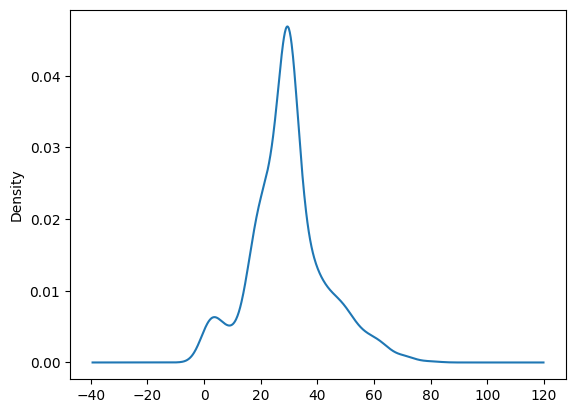

In [190]:
dst['Age'].plot(kind='kde')

(array([646.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 168.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  77.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]),
 <BarContainer object of 20 artists>)

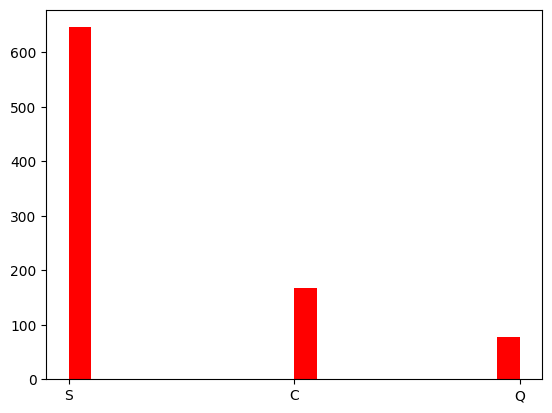

In [191]:
import matplotlib.pyplot as plt
plt.hist(dst['Embarked'],color='red',bins=20)

## Z-Score

In [192]:
age_std = dst['Age'].std()
print(age_std)

13.002015226002884


In [193]:
dst['Age Z-Score'] = (dst['Age'] - dst['Age'].mean()) / age_std
dst

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age Z-Score
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S,-0.592148
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0.638430
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S,-0.284503
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0.407697
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S,0.407697
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S,-0.207592
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,-0.822881
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S,0.000000
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,-0.284503


In [194]:
from scipy.stats import zscore
dst['Age Z-Score'] = zscore(dst['Age'], nan_policy='omit')
dst = dst[(dst['Age Z-Score'] >= -3) & (dst['Age Z-Score'] <= 3)]
dst

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age Z-Score
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S,-0.592481
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0.638789
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S,-0.284663
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0.407926
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S,0.407926
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S,-0.207709
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,-0.823344
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S,0.000000
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,-0.284663


If the Z-Score absolute is greater than 3 Standard Deviations, We can consider it as an outlier

## Inter Quartile Range IQR Method

This is the most common method used in real world preprocessing

{'whiskers': [<matplotlib.lines.Line2D at 0x1f3826d9810>,
 'caps': [<matplotlib.lines.Line2D at 0x1f3826d9a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f3826d96d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1f3826d9d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f3826d9e50>],
 'means': []}

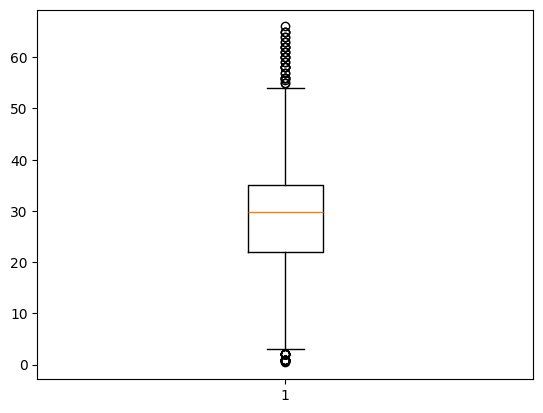

In [195]:
plt.boxplot(dst['Age'])

Q1 = 25 percentile
Q2 = 50 percentile (median)
Q3 = 75 percentile

In [196]:
q1 = dst['Age'].quantile(0.25)
q3 = dst['Age'].quantile(0.75)
print(f"Q1: {q1}")
print(f"Q3: {q3}")
iqr = q3 - q1
print("IQR:",iqr)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5


## Transformation Methods

In [197]:
emp

,Employee_ID,Age,Gender,Department,Experience_Years,Performance_Score,Salary
0,E0524,49,Female,Operations,5.6,67.800000,33013.0
1,E0603,55,Female,Sales,5.5,69.614951,42640.0
2,E0527,29,Female,Sales,10.7,68.800000,72180.0
3,E0032,30,Female,Operations,9.8,69.963255,65750.0
4,E0617,58,Male,Sales,11.5,72.800000,74830.0
...,...,...,...,...,...,...,...
1015,E0107,26,Male,IT,9.2,83.900000,51410.0
1016,E0271,40,Female,Finance,4.8,77.400000,48858.0
1017,E0861,47,Male,Operations,2.0,76.500000,24647.0
1018,E0436,57,Male,HR,1.8,55.700000,26744.0


### Log Transformation

In [198]:
emp['salary_log'] = np.log1p(emp['Salary'])
emp[['Salary', 'salary_log']]

,Salary,salary_log
0,33013.0,10.404687
1,42640.0,10.660572
2,72180.0,11.186932
3,65750.0,11.093630
4,74830.0,11.222988
...,...,...
1015,51410.0,10.847607
1016,48858.0,10.796694
1017,24647.0,10.112451
1018,26744.0,10.194103


### Square Root Transformation

In [199]:
emp['salary_sqrt'] = np.sqrt(emp['Salary'])
emp[['Salary', 'salary_sqrt']]

,Salary,salary_sqrt
0,33013.0,181.694799
1,42640.0,206.494552
2,72180.0,268.663358
3,65750.0,256.417628
4,74830.0,273.550727
...,...,...
1015,51410.0,226.737734
1016,48858.0,221.038458
1017,24647.0,156.993630
1018,26744.0,163.535929


## Capping and Flooring

In [200]:
dst['age_capped'] = dst['Age'].clip(lower=lower_bound, upper=upper_bound)
dst

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age Z-Score,age_capped
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S,-0.592481,22.000000
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0.638789,38.000000
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S,-0.284663,26.000000
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0.407926,35.000000
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S,0.407926,35.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S,-0.207709,27.000000
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,-0.823344,19.000000
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S,0.000000,29.699118
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,-0.284663,26.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x1f38274d090>,
 'caps': [<matplotlib.lines.Line2D at 0x1f38274d310>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f38274cf50>],
 'medians': [<matplotlib.lines.Line2D at 0x1f38274d590>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f38274d6d0>],
 'means': []}

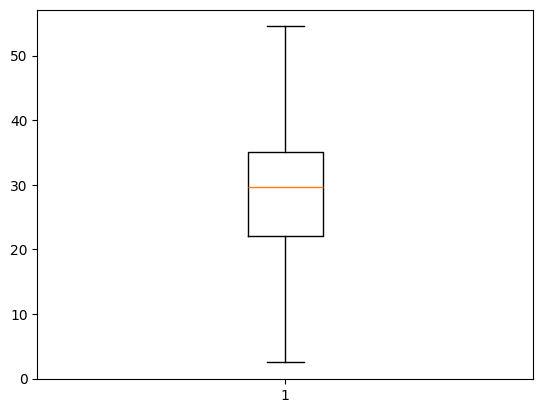

In [201]:
plt.boxplot(dst['age_capped'])

# Feature Scaling

## Normalization: Min-Max Scaler

In [202]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
emp_minmax_scaled = emp.copy()
emp_minmax_scaled = emp_minmax_scaled.drop(columns=['salary_log', 'salary_sqrt'])
emp_minmax_scaled[['Age', 'Experience_Years', 'Performance_Score', 'Salary']] = scaler.fit_transform(emp_minmax_scaled[['Age', 'Experience_Years', 'Performance_Score', 'Salary']])
emp_minmax_scaled.head()

,Employee_ID,Age,Gender,Department,Experience_Years,Performance_Score,Salary
0,E0524,0.729730,Female,Operations,0.333333,0.504174,0.070919
1,E0603,0.891892,Female,Sales,0.327381,0.534473,0.095291
2,E0527,0.189189,Female,Sales,0.636905,0.520868,0.170076
3,E0032,0.216216,Female,Operations,0.583333,0.540288,0.153797
4,E0617,0.972973,Male,Sales,0.684524,0.587646,0.176785


In [203]:
emp_minmax_scaled.describe()

,Age,Experience_Years,Performance_Score,Salary
count,1020.000000,1020.000000,1020.000000,1020.000000
mean,0.510758,0.429179,0.536786,0.121280
std,0.301623,0.179881,0.163403,0.083587
min,0.000000,0.000000,0.000000,0.000000
25%,0.243243,0.315476,0.429048,0.085741
50%,0.540541,0.430555,0.537641,0.115432
75%,0.756757,0.547619,0.647746,0.141732
max,1.000000,1.000000,1.000000,1.000000


## Standardization: Z-Score Standardization - StandardScaler

In [204]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
emp_zscore_scaled = emp.copy()
emp_zscore_scaled = emp_zscore_scaled.drop(columns=['salary_log', 'salary_sqrt'])
emp_zscore_scaled[['Age', 'Experience_Years', 'Performance_Score', 'Salary']] = scaler.fit_transform(emp_zscore_scaled[['Age', 'Experience_Years', 'Performance_Score', 'Salary']])
emp_zscore_scaled.head()

,Employee_ID,Age,Gender,Department,Experience_Years,Performance_Score,Salary
0,E0524,0.726334,Female,Operations,-0.533089,-0.199680,-0.602802
1,E0603,1.264229,Female,Sales,-0.566196,-0.014160,-0.311080
2,E0527,-1.066650,Female,Sales,1.155361,-0.097462,0.584058
3,E0032,-0.977000,Female,Operations,0.857399,0.021443,0.389212
4,E0617,1.533177,Male,Sales,1.420216,0.311408,0.664359


In [205]:
emp_zscore_scaled.describe()

,Age,Experience_Years,Performance_Score,Salary
count,1.020000e+03,1.020000e+03,1.020000e+03,1.020000e+03
mean,-3.570129e-17,-2.960595e-16,8.881784e-17,6.443647e-17
std,1.000491e+00,1.000491e+00,1.000491e+00,1.000491e+00
min,-1.694194e+00,-2.387073e+00,-3.286649e+00,-1.451667e+00
25%,-8.873512e-01,-6.324097e-01,-6.596588e-01,-4.253883e-01
50%,9.878989e-02,7.652050e-03,5.233241e-03,-7.000767e-02
75%,8.159834e-01,6.587579e-01,6.793909e-01,2.447979e-01
max,1.622826e+00,3.174879e+00,2.836181e+00,1.051784e+01


## Robust Scaling

In [206]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
emp_robust_scaled = emp.copy()
emp_robust_scaled = emp_robust_scaled.drop(columns=['salary_log', 'salary_sqrt'])
emp_robust_scaled[['Age', 'Experience_Years', 'Performance_Score', 'Salary']] = scaler.fit_transform(emp_robust_scaled[['Age', 'Experience_Years', 'Performance_Score', 'Salary']])
emp_robust_scaled.head()

,Employee_ID,Age,Gender,Department,Experience_Years,Performance_Score,Salary
0,E0524,0.368421,Female,Operations,-0.418800,-0.153029,-0.794995
1,E0603,0.684211,Female,Sales,-0.444441,-0.014483,-0.359709
2,E0527,-0.684211,Female,Sales,0.888892,-0.076693,0.975946
3,E0032,-0.631579,Female,Operations,0.658123,0.012105,0.685212
4,E0617,0.842105,Male,Sales,1.094020,0.228651,1.095766


In [207]:
emp_robust_scaled.describe()

,Age,Experience_Years,Performance_Score,Salary
count,1020.000000,1.020000e+03,1.020000e+03,1020.000000
mean,-0.057998,-5.926458e-03,-3.908175e-03,0.104460
std,0.587372,7.748727e-01,7.471646e-01,1.492855
min,-1.052632,-1.854698e+00,-2.458372e+00,-2.061606
25%,-0.578947,-4.957232e-01,-4.965402e-01,-0.530272
50%,0.000000,-1.138412e-16,-5.423721e-16,0.000000
75%,0.421053,5.042768e-01,5.034598e-01,0.469728
max,0.894737,2.452995e+00,2.114147e+00,15.798363


## Comparison

### MinMaxScaler

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Experience_Years'}>],
       [<Axes: title={'center': 'Performance_Score'}>,
        <Axes: title={'center': 'Salary'}>]], dtype=object)

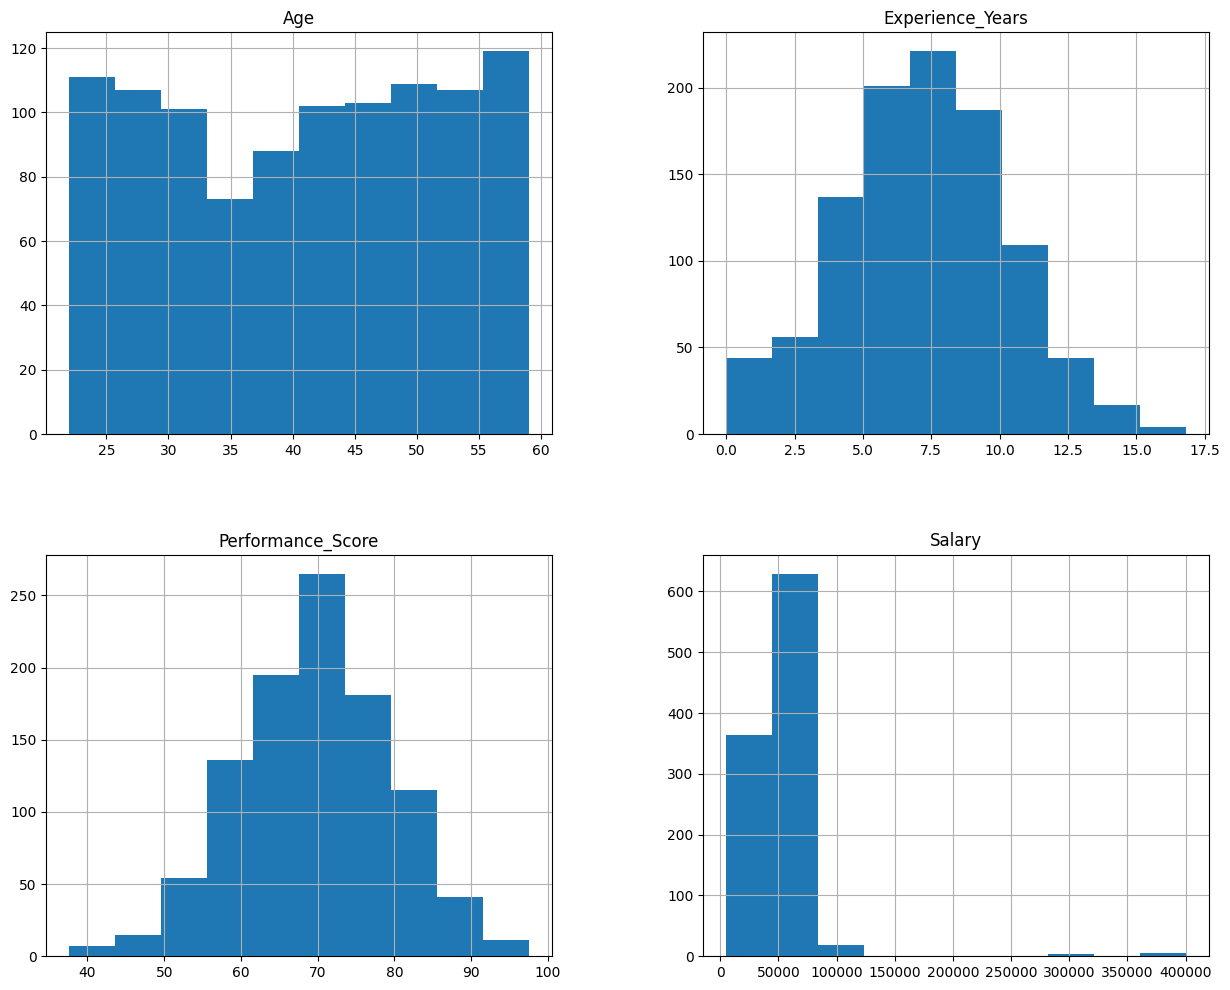

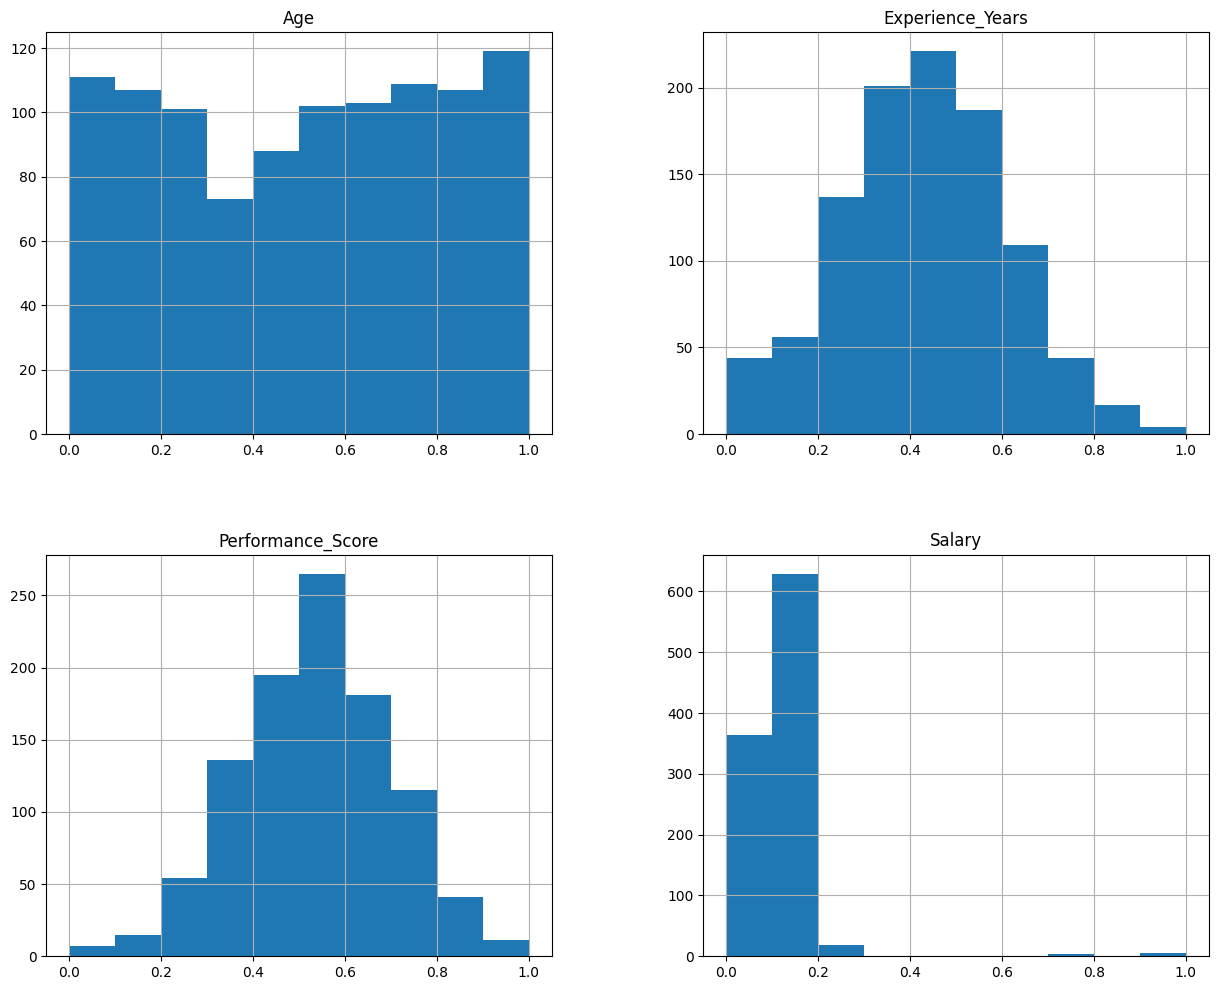

In [208]:
emp[['Age', 'Experience_Years', 'Performance_Score', 'Salary']].hist(figsize=(15, 12))
emp_minmax_scaled.hist(figsize=(15,12))

### StandardScaler - Z-Score Standardization

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Experience_Years'}>],
       [<Axes: title={'center': 'Performance_Score'}>,
        <Axes: title={'center': 'Salary'}>]], dtype=object)

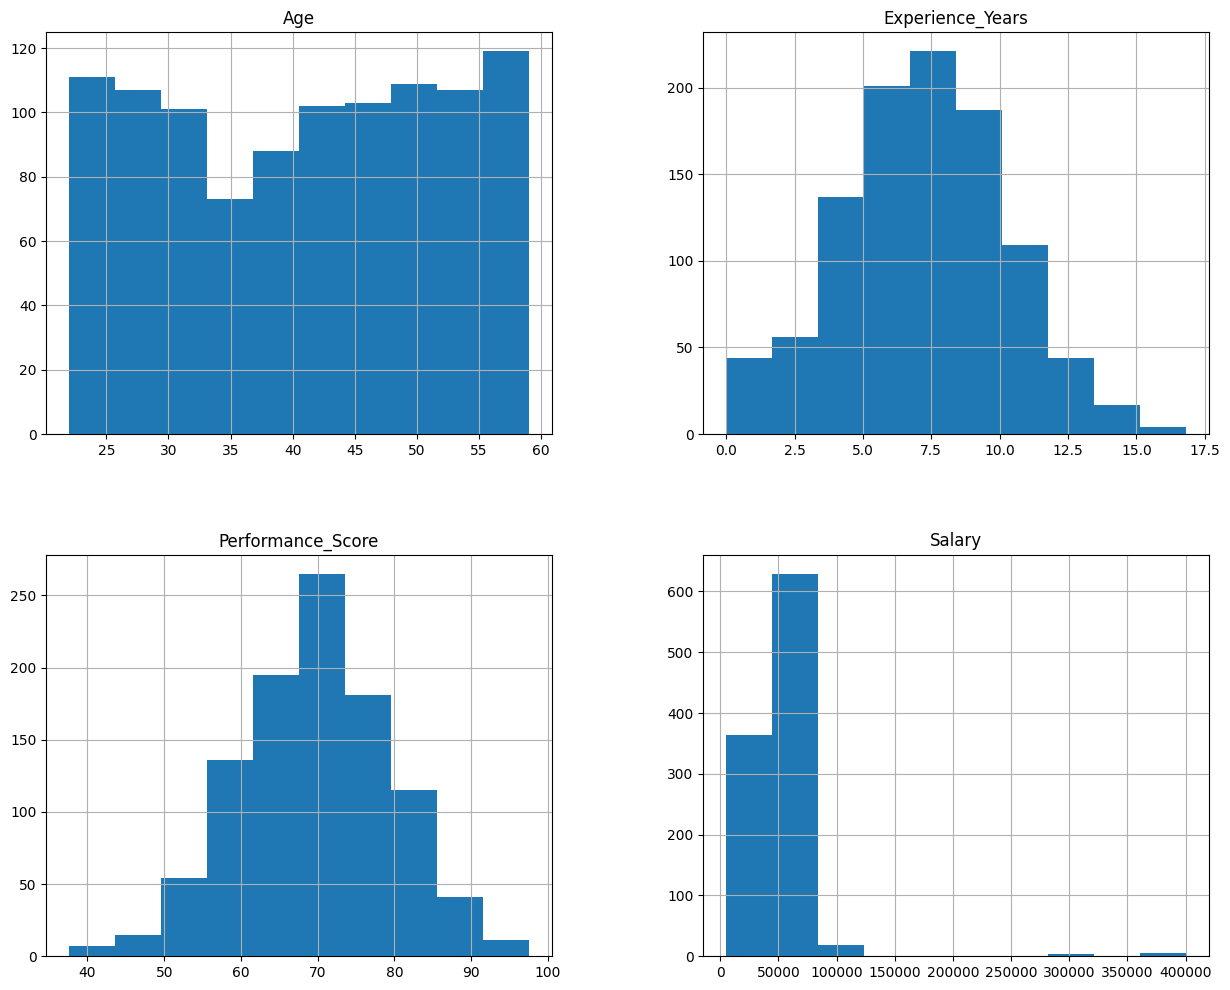

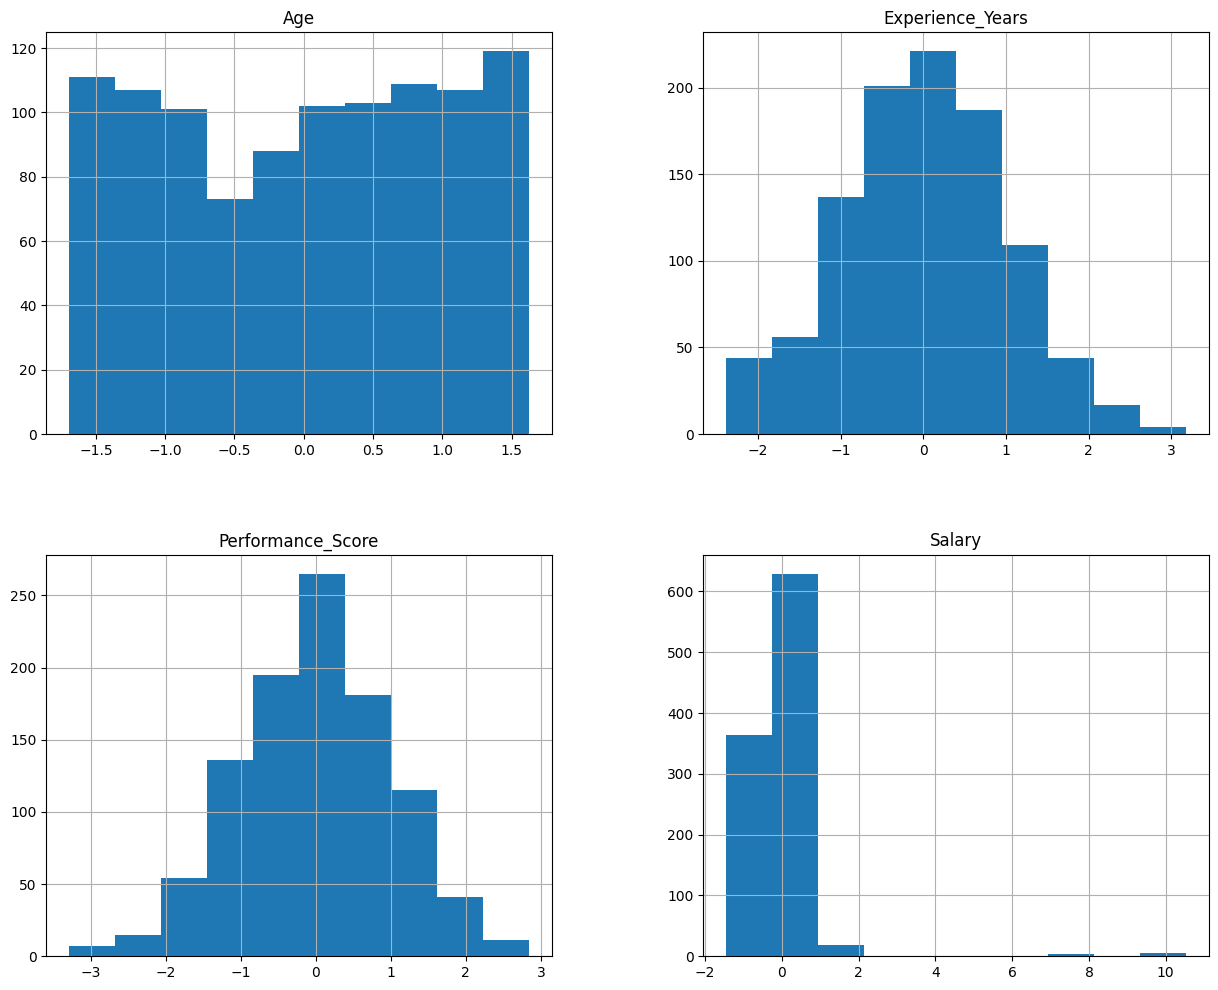

In [209]:
emp[['Age', 'Experience_Years', 'Performance_Score', 'Salary']].hist(figsize=(15, 12))
emp_zscore_scaled.hist(figsize=(15,12))

### Robust Scaling

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Experience_Years'}>],
       [<Axes: title={'center': 'Performance_Score'}>,
        <Axes: title={'center': 'Salary'}>]], dtype=object)

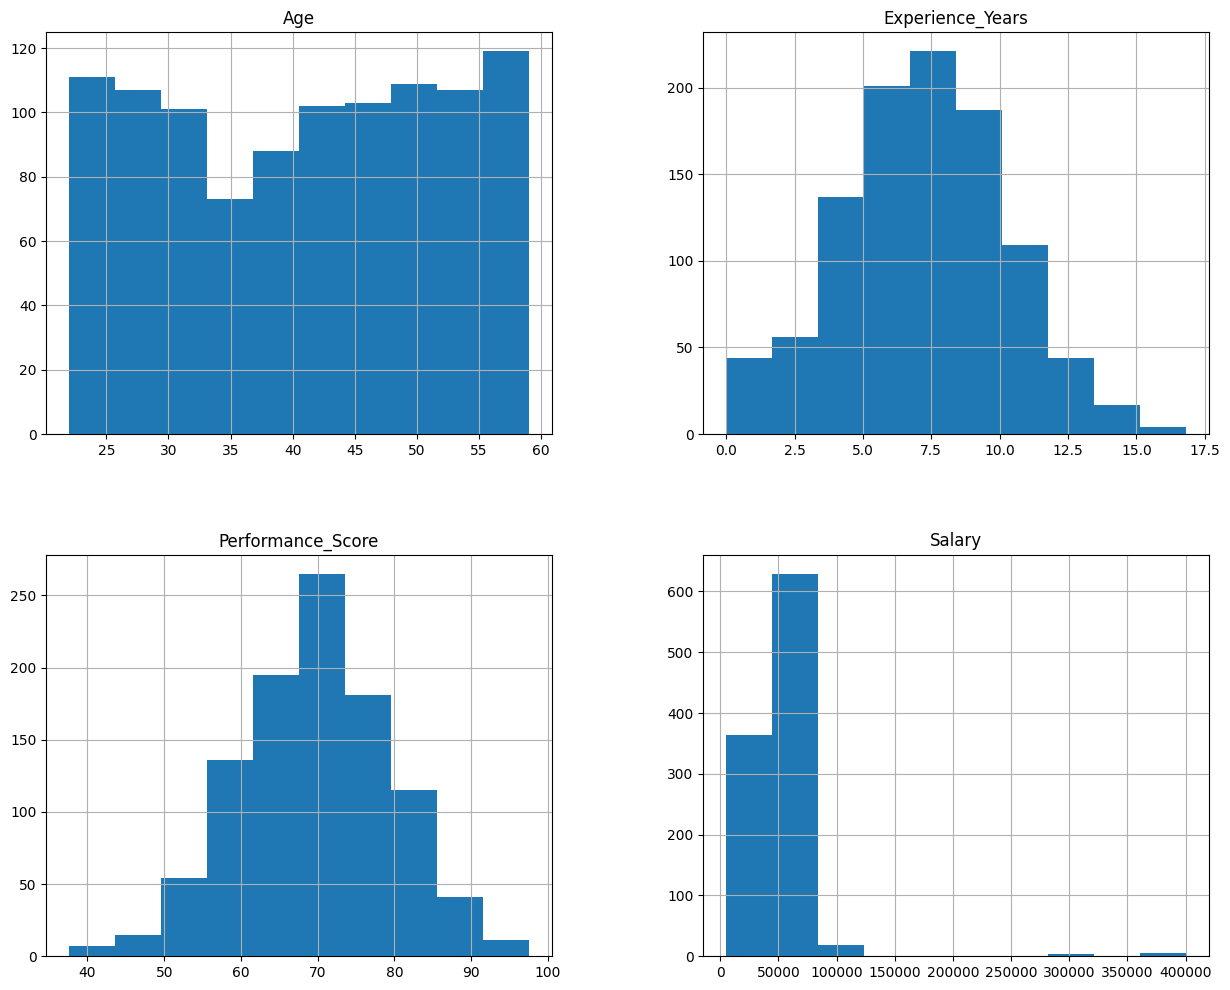

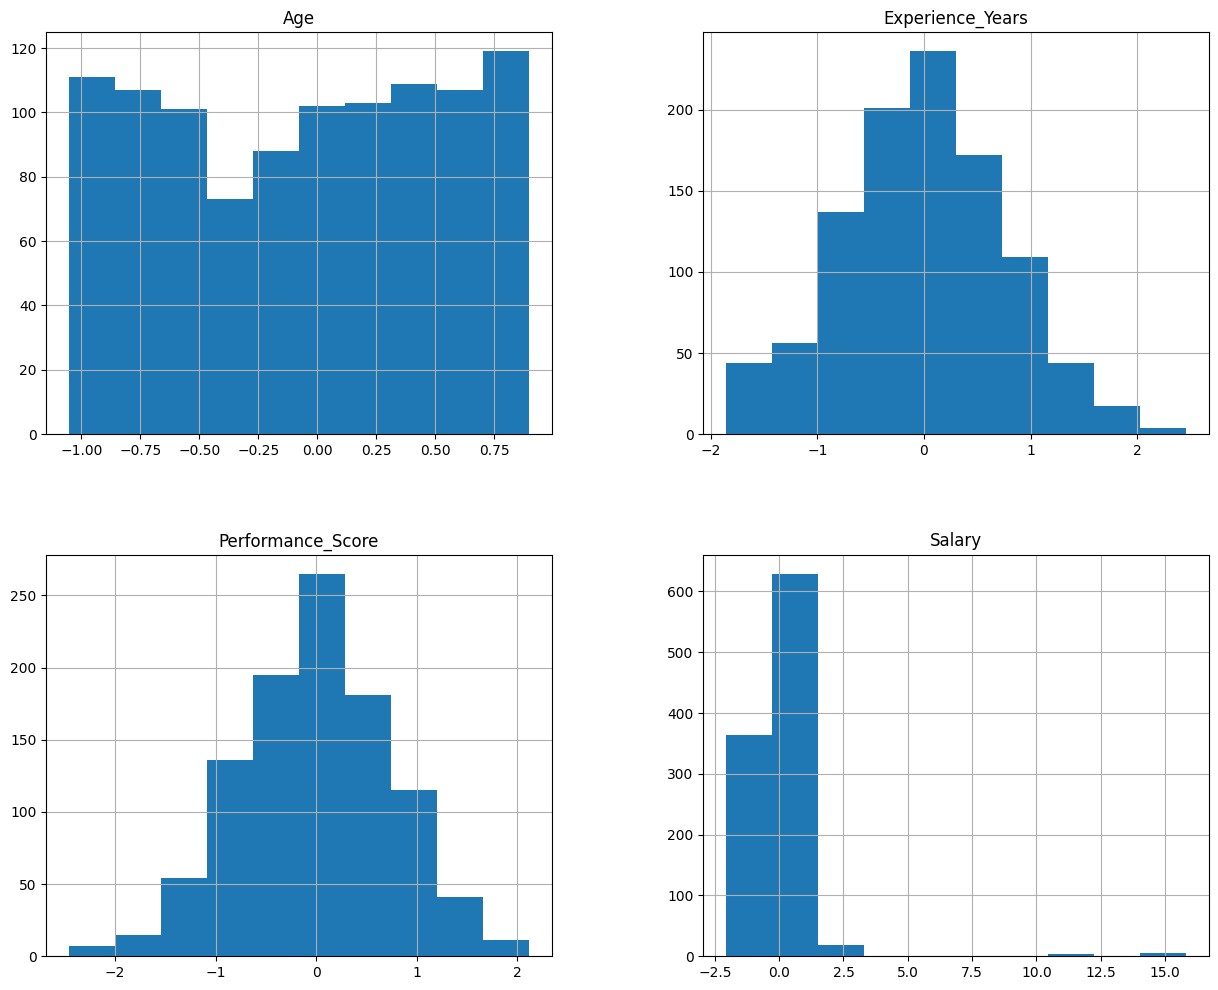

In [210]:
emp[['Age', 'Experience_Years', 'Performance_Score', 'Salary']].hist(figsize=(15, 12))
emp_robust_scaled.hist(figsize=(15,12))

# Feature Engineering

## Encoding Categorical Values

### Label Encoding

In [211]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
emp_encoded = emp.copy()
emp_encoded['Gender_Label'] = encoder.fit_transform(emp_encoded['Gender'])
emp_encoded

,Employee_ID,Age,Gender,Department,Experience_Years,Performance_Score,Salary,salary_log,salary_sqrt,Gender_Label
0,E0524,49,Female,Operations,5.6,67.800000,33013.0,10.404687,181.694799,0
1,E0603,55,Female,Sales,5.5,69.614951,42640.0,10.660572,206.494552,0
2,E0527,29,Female,Sales,10.7,68.800000,72180.0,11.186932,268.663358,0
3,E0032,30,Female,Operations,9.8,69.963255,65750.0,11.093630,256.417628,0
4,E0617,58,Male,Sales,11.5,72.800000,74830.0,11.222988,273.550727,1
...,...,...,...,...,...,...,...,...,...,...
1015,E0107,26,Male,IT,9.2,83.900000,51410.0,10.847607,226.737734,1
1016,E0271,40,Female,Finance,4.8,77.400000,48858.0,10.796694,221.038458,0
1017,E0861,47,Male,Operations,2.0,76.500000,24647.0,10.112451,156.993630,1
1018,E0436,57,Male,HR,1.8,55.700000,26744.0,10.194103,163.535929,1


### One-Hot Encoding

In [212]:
emp_encoded = pd.get_dummies(
    emp_encoded,
    columns = ['Department'],
    dtype = int
)

emp_encoded

,Employee_ID,Age,Gender,Experience_Years,Performance_Score,Salary,salary_log,salary_sqrt,Gender_Label,Department_Finance,Department_HR,Department_IT,Department_Marketing,Department_Operations,Department_Sales
0,E0524,49,Female,5.6,67.800000,33013.0,10.404687,181.694799,0,0,0,0,0,1,0
1,E0603,55,Female,5.5,69.614951,42640.0,10.660572,206.494552,0,0,0,0,0,0,1
2,E0527,29,Female,10.7,68.800000,72180.0,11.186932,268.663358,0,0,0,0,0,0,1
3,E0032,30,Female,9.8,69.963255,65750.0,11.093630,256.417628,0,0,0,0,0,1,0
4,E0617,58,Male,11.5,72.800000,74830.0,11.222988,273.550727,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,E0107,26,Male,9.2,83.900000,51410.0,10.847607,226.737734,1,0,0,1,0,0,0
1016,E0271,40,Female,4.8,77.400000,48858.0,10.796694,221.038458,0,1,0,0,0,0,0
1017,E0861,47,Male,2.0,76.500000,24647.0,10.112451,156.993630,1,0,0,0,0,1,0
1018,E0436,57,Male,1.8,55.700000,26744.0,10.194103,163.535929,1,0,1,0,0,0,0


# Feature Selection

## Filter Methods

### Correlation Based Selection

In [213]:
emp.corr(numeric_only=True)

,Age,Experience_Years,Performance_Score,Salary,salary_log,salary_sqrt
Age,1.000000,0.031202,0.048032,-0.005772,0.019876,0.009905
Experience_Years,0.031202,1.000000,0.046321,0.475442,0.806660,0.685763
Performance_Score,0.048032,0.046321,1.000000,0.096970,0.149637,0.132833
Salary,-0.005772,0.475442,0.096970,1.000000,0.823764,0.951759
salary_log,0.019876,0.806660,0.149637,0.823764,1.000000,0.956626
salary_sqrt,0.009905,0.685763,0.132833,0.951759,0.956626,1.000000


### Varience Threshold

In [214]:
emp_numeric_only = emp.select_dtypes(include='number')

from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0)
emp_selected = pd.DataFrame(
    selector.fit_transform(emp_numeric_only),
    columns=selector.get_feature_names_out()
)

emp_numeric_only

,Age,Experience_Years,Performance_Score,Salary,salary_log,salary_sqrt
0,49,5.6,67.800000,33013.0,10.404687,181.694799
1,55,5.5,69.614951,42640.0,10.660572,206.494552
2,29,10.7,68.800000,72180.0,11.186932,268.663358
3,30,9.8,69.963255,65750.0,11.093630,256.417628
4,58,11.5,72.800000,74830.0,11.222988,273.550727
...,...,...,...,...,...,...
1015,26,9.2,83.900000,51410.0,10.847607,226.737734
1016,40,4.8,77.400000,48858.0,10.796694,221.038458
1017,47,2.0,76.500000,24647.0,10.112451,156.993630
1018,57,1.8,55.700000,26744.0,10.194103,163.535929


In [215]:
emp_selected

,Age,Experience_Years,Performance_Score,Salary,salary_log,salary_sqrt
0,49.0,5.6,67.800000,33013.0,10.404687,181.694799
1,55.0,5.5,69.614951,42640.0,10.660572,206.494552
2,29.0,10.7,68.800000,72180.0,11.186932,268.663358
3,30.0,9.8,69.963255,65750.0,11.093630,256.417628
4,58.0,11.5,72.800000,74830.0,11.222988,273.550727
...,...,...,...,...,...,...
1015,26.0,9.2,83.900000,51410.0,10.847607,226.737734
1016,40.0,4.8,77.400000,48858.0,10.796694,221.038458
1017,47.0,2.0,76.500000,24647.0,10.112451,156.993630
1018,57.0,1.8,55.700000,26744.0,10.194103,163.535929


## Wrapper Method

### Recursive Feature Elimination (RFE)

In [216]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

X = emp[['Age', 'Experience_Years', 'Performance_Score']]
y = emp['Salary']

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=2)
rfe.fit(X, y)

for column, selected in zip(X.columns, rfe.support_):
    print(f"{column}: {selected}")

Age: False
Experience_Years: True
Performance_Score: True


### Stepwise Selection

#### Forward Selection

In [217]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()
sfs = SequentialFeatureSelector(estimator=model, n_features_to_select=2, direction='forward')
sfs.fit(X, y)

for column, selected in zip(X, sfs.support_):
    print(f"{column}: {selected}")

Age: False
Experience_Years: True
Performance_Score: True


#### Backward Selection

In [218]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

model = LinearRegression()
sfs = SequentialFeatureSelector(estimator=model, n_features_to_select=2, direction='backward')
sfs.fit(X, y)

for column, selected in zip(X, sfs.support_):
    print(f"{column}: {selected}")

Age: False
Experience_Years: True
Performance_Score: True


## Embedded Methods

### Lasso Regression (L1 Regulation)

In [219]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1)
X = emp[['Age', 'Experience_Years', 'Performance_Score']]
y = emp['Salary']

lasso.fit(X, y)
for feature, coef in zip(X.columns, lasso.coef_):
    print(f"{feature}: {coef}")

emp_lasso_selected = emp[X.columns[lasso.coef_ != 0]]
emp_lasso_selected

Age: -71.53012984046572
Experience_Years: 5163.963490364242
Performance_Score: 257.1570669702369


,Age,Experience_Years,Performance_Score
0,49,5.6,67.800000
1,55,5.5,69.614951
2,29,10.7,68.800000
3,30,9.8,69.963255
4,58,11.5,72.800000
...,...,...,...
1015,26,9.2,83.900000
1016,40,4.8,77.400000
1017,47,2.0,76.500000
1018,57,1.8,55.700000


In [220]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X, y)

for feature, coef in zip(X.columns, ridge.coef_):
    print(f"{feature}: {coef}")

Age: -71.5344204460135
Experience_Years: 5163.516602462105
Performance_Score: 257.1715072562291
